# DSCI 100 Project: Predicting Subscriber Status







## Introduction

### Background
The Pacific Laboratory for Artificial Intelligence (PLAI) is a research group within the Department of Computer Science at UBC, established in 2018 by Professor Frank Wood. PLAI is dedicated to advancing artificial intelligence through research in generative modelling, reinforcement learning, and probabilistic programming (Wood, n.d.-b). The lab's mission is to develop safe and reliable AI. One of PLAI's flagship projects is PLAICraft, an initiative that merges the world of Minecraft with AI research. PLAICraft provides a cloud-based platform where participants can play Minecraft in their web browsers. This platform is designed to collect behavioural data from players, including audio interactions, keystrokes, mouse movements, and video footage (Wood, n.d.-a). The goal is to gather over 10,000 hours of gameplay data to train advanced AI agents capable of understanding and responding to complex, naturalistic human behaviours within virtual environments (Smith, n.d.). By analyzing these gameplay sessions, PLAI aims to develop AI agents that can think, act, and learn within simulated settings, a lot like human behaviour. This research has the potential to revolutionize the development of AI that interacts seamlessly with humans (Pacific Laboratory for Artificial Intelligence, n.d.). Therefore, the researchers are interested in identifying the types of players who tend to generate large amounts of gameplay data that allow them to recruit people who will help improve the AI's training.

### Dataset

This report utilizes the `players.csv` dataset to formulate and answer a defined research question (see below). This dataset offers information about various player statistics for 196 participants who took part in the Minecraft data-collection event. Namely, it consists of 7 variables outlined in the table below:
 
#### Variables in `players.csv`

| Variable         | Type         | Description                                                                                   |
|------------------|--------------|----------------------------------------------------------------------------------------------|
| `experience`     | character    | Describes the player’s experience level with Minecraft, categorized into Pro, Veteran, Amateur, Regular, and Beginner. |
| `subscribe`      | logical      | Indicates if the player is subscribed to the PLAICRAFT mailing list or not.                   |
| `hashedemail`    | character    | Many email addresses that have been converted into a fixed-length string of characters using a cryptographic hashing function. This technique is often used for security, privacy, and data protection. |
| `played_hours`    | double       | The number of hours the player has spent on the server.                                       |
| `name`           | character    | The username that the player goes by.                                                         |
| `gender`         | character    | What the player identifies as.                                                                |
| `Age`            | double       | How old the player is (years).                    

### Project Question 

- In this report, we attempt to answer the **specific** question: Can `played_hours` and `age` predict `subscribe` in `players.csv`? 

- This falls under the first **broad** question provided: What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

- In essence, this question is asking if two provided player data categories, age and the number of played hours, are reliable predictors of whether or not a player will subscribe to a game-related newsletter. 





## Methods and Results (Overview)

#### 1. Loading Dataset
#### 2. Wrangling & Calculating Summary Statistics
#### 3. Exploratory Visualizations
#### 4. Data Analysis
#### 5. Results & Analysis Visualization


In [17]:
# Loading packages
library(tidyverse)
library(repr)
library(themis)
library(tidymodels)
library(yardstick)
options(repr.matrix.max.rows = 6)

## 1. Loading Dataset

In [15]:

players <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/players.csv")   # Player demographics and subscription info
sessions <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/sessions.csv")  # Gameplay session data

players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,17
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


## 2. Tidying up the dataset and calculating summary statistics

In [21]:
# Clean players dataset
players <- players |>
  select(played_hours, Age, subscribe) |> 
  rename(age = Age) |>                                                     
  mutate(
    subscriber_status = factor(
      subscribe,
      levels = c(FALSE, TRUE),
      labels = c("Non-subscriber", "Subscriber")
    )
  ) |>                                                                    
  select(-subscribe)                                                    

# Generate summary statistics by subscription status
subscription_summary <- players |>
  group_by(subscriber_status) |>        
  summarize(
    amount        = n(),          
    percent       = amount / nrow(players),
    mean_age      = mean(age, na.rm = TRUE), 
    mean_hours    = mean(played_hours), 
    median_age    = median(age, na.rm = TRUE),
    median_hours  = median(played_hours), 
    sd_age        = sd(age, na.rm = TRUE),     
    sd_hours      = sd(played_hours),
    na_age        = sum(is.na(age)),
    na_hours      = sum(is.na(played_hours))                              
  ) |>
  mutate(percent = percent(percent, accuracy = 0.1))                  

# Remove players with NA values
players <- players |> 
  drop_na(played_hours, age, subscriber_status)

subscription_summary

subscriber_status,amount,percent,mean_age,mean_hours,median_age,median_hours,sd_age,sd_hours,na_age,na_hours
<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Non-subscriber,52,26.5%,22.98077,0.5019231,21,0.0,8.166143,1.188258,0,0
Subscriber,144,73.5%,19.61972,7.7756944,18,0.1,5.001748,32.892470,2,0


In [22]:
# Create a recipe to preprocess the data for modeling
player_recipe <- recipe(subscriber_status ~ played_hours + age, data = players) |>
  step_scale(all_predictors()) |>  
  step_center(all_predictors()) |> 
  # Upsample minority class to be 75% of majority 
  step_upsample(subscriber_status, over_ratio = 0.75, skip = FALSE) |>    
  prep()

baked_data <- bake(player_recipe, new_data = players)

baked_data

# Checks class balance in the baked_data after upsampling
baked_data |>
  count(subscriber_status)

played_hours,age,subscriber_status
<dbl>,<dbl>,<fct>
-0.2071953,0.8873970,Non-subscriber
-0.1721051,0.8873970,Non-subscriber
-0.2071953,0.4015409,Non-subscriber
⋮,⋮,⋮
-0.2071953,-0.08431524,Subscriber
0.4419745,4.61229412,Subscriber
7.4459910,-0.08431524,Subscriber


subscriber_status,n
<fct>,<int>
Non-subscriber,106
Subscriber,142


## 3. Visualizations to get more knowledge about the data

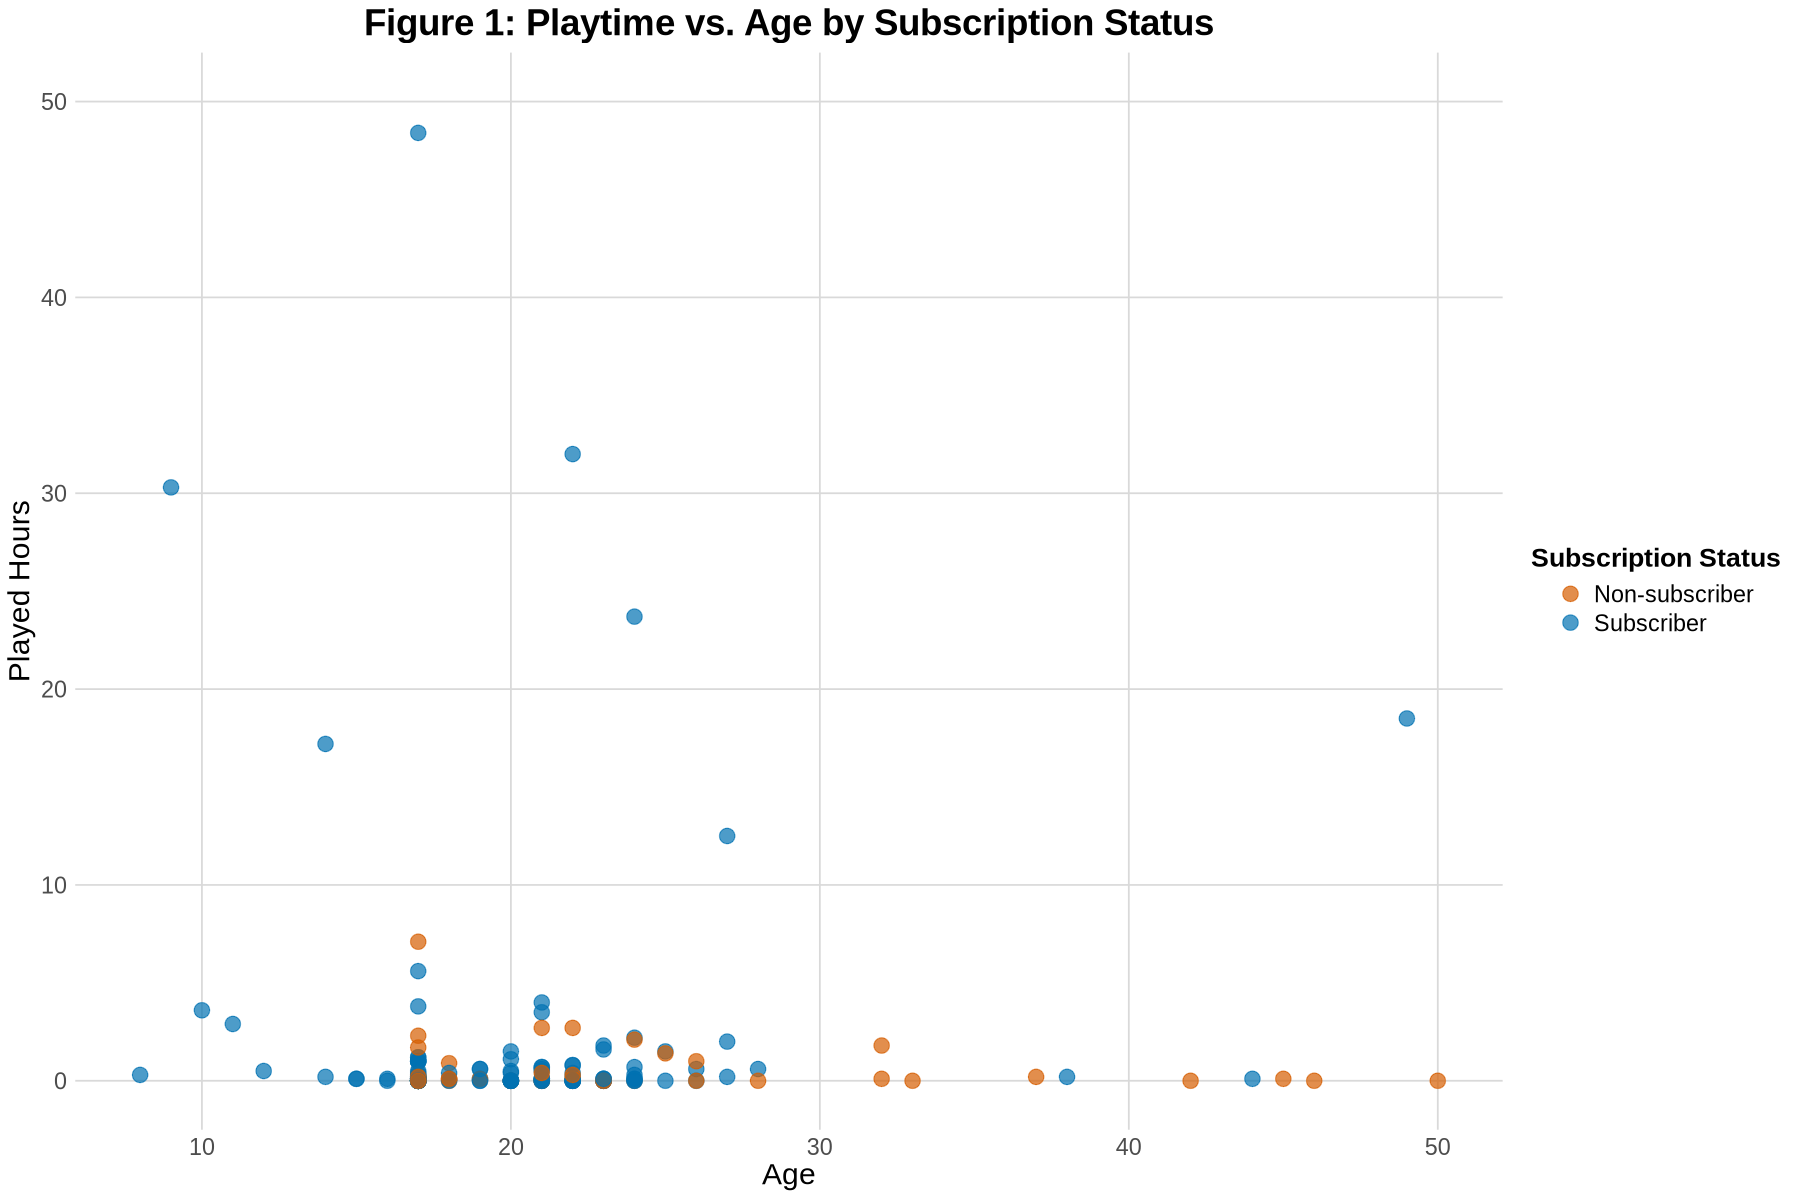

In [23]:
options(repr.plot.width = 15, repr.plot.height = 10)

ggplot(players, aes(x = age, y = played_hours, color = subscriber_status)) +
  geom_point(alpha = 0.7, size = 4) +                             
  labs(
    title = "Figure 1: Playtime vs. Age by Subscription Status",                
    x = "Age",                                                         
    y = "Played Hours",                                               
    color = "Subscription Status"                                     
  ) +
  coord_cartesian(ylim = c(0, 50)) +                                  
  scale_color_manual(values = c("Non-subscriber" = "#D55E00", "Subscriber" = "#0072B2")) +  
  theme_minimal() +                                                
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 22),
    axis.text = element_text(size = 14),
    axis.title = element_text(size = 18),
    legend.title = element_text(face = "bold", size = 16, hjust = 0.5), 
    legend.text = element_text(size = 14),
    panel.grid.major = element_line(color = "grey85"),
    panel.grid.minor = element_blank()
  )

## 4. Data Analysis (Establishing classification model/recipe & finding best k) 

In [24]:
# Create a tibble with the different k values from 1 to 40 to evalute for KNN
k_vals <- tibble(neighbors = seq(from = 1, to = 40, by = 1))

# Create a function to tune KNN for a random seed
tune_knn_for_seed <- function(seed) {

  set.seed(seed)
  
  # Split the baked_data into training and testing sets (75% train, 25% test)
  players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
  training_set <- training(players_split)
  testing_set <- testing(players_split)

  # Create a recipe
  player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
    step_scale(all_predictors()) |>
    step_center(all_predictors())
  
  # Create a tunable KNN model specification
  knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
    set_engine("kknn") |>
    set_mode("classification")
  
  # Create 10-fold cross-validation folds 
  cv_folds <- vfold_cv(training_set, v = 10, strata = subscriber_status)
  
  # Set up a workflow
  tuned <- workflow() |>
    add_recipe(player_recipe_training) |>
    add_model(knn_spec) |>
    tune_grid(
      resamples = cv_folds,
      grid = k_vals     
    ) |>
    collect_metrics() |>  
    filter(.metric == "accuracy") |>
    mutate(seed = seed)
  
  return(tuned)
}

# Repeats the tuning process 20 seeds to ensure our tuning is not biased to one random split 
# in the data. Then combine the results.
seeds <- 1:20
all_knn_results <- map_dfr(seeds, tune_knn_for_seed) 


In [26]:
# The average accuracy for each k value across all seeds from (1:20)
mean_accuracies <- all_knn_results |> 
  group_by(neighbors) |> 
  summarise(mean_accuracy = mean(mean), 
            .groups = "drop")   

mean_accuracies

# View the best 3 k values based on average accuracy
best_k <- mean_accuracies |> 
  arrange(desc(mean_accuracy)) |> 
  slice(1:3) |>   
  pull(neighbors) 


best_k


neighbors,mean_accuracy
<dbl>,<dbl>
1,0.7115316
2,0.7011687
3,0.6480908
⋮,⋮
38,0.6222386
39,0.6211816
40,0.6214336


[1]  1  2 10

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”


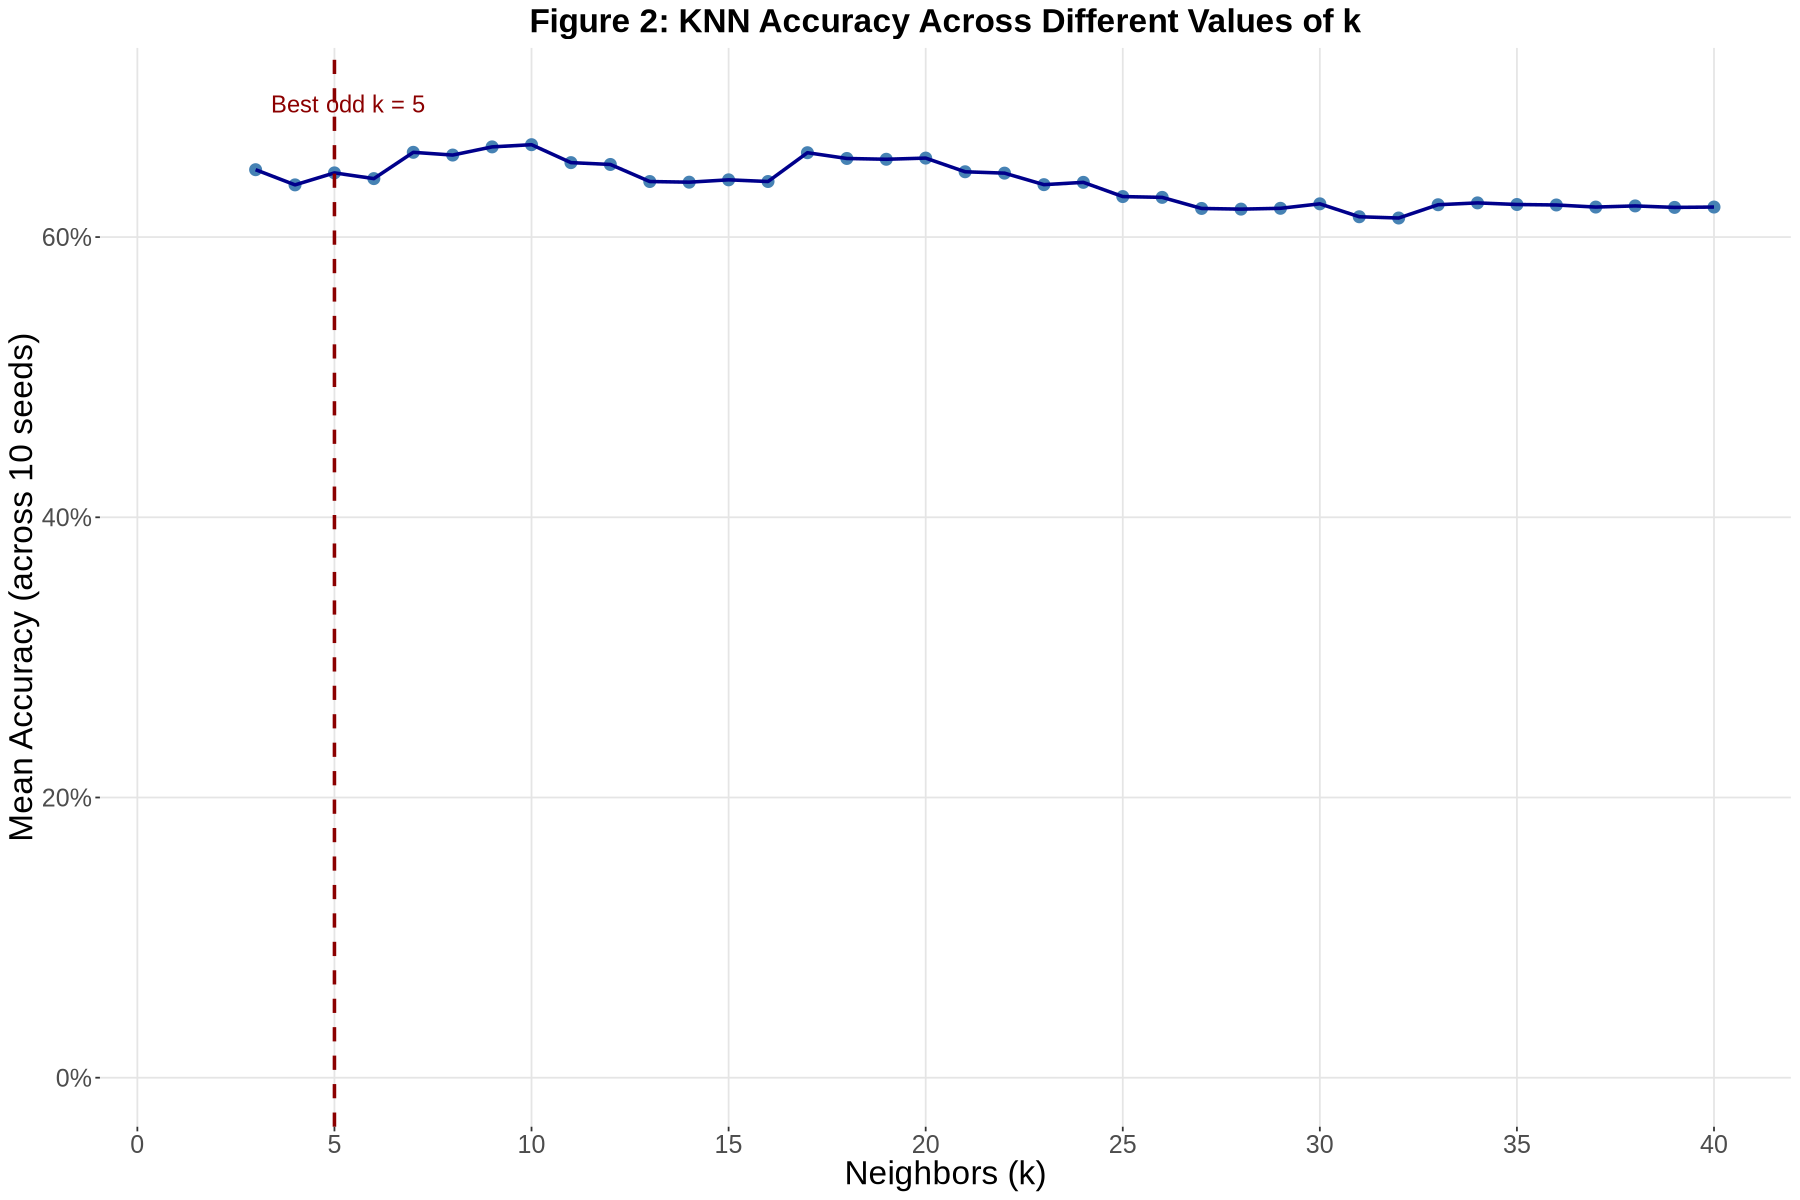

In [27]:
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(mean_accuracies, aes(x = neighbors, y = mean_accuracy)) +
  geom_point(size = 3, color = "steelblue") +                      
  geom_line(color = "darkblue", linewidth = 1) +                    
  labs(
    title = "Figure 2: KNN Accuracy Across Different Values of k",
    x = "Neighbors (k)",
    y = "Mean Accuracy (across 10 seeds)"
  ) +
  scale_x_continuous(breaks = seq(0, 40, by = 5)) +                 
  scale_y_continuous(limits = c(0, 0.7), labels = scales::percent_format(accuracy = 1)) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20), 
    axis.text.x = element_text(size = 15),                            
    axis.text.y = element_text(size = 15),
    axis.title.x = element_text(size = 20),                           
    axis.title.y = element_text(size = 20),
    panel.background = element_rect(fill = "white"),                 
    panel.grid.major = element_line(color = "grey90"),               
    panel.grid.minor = element_blank()
  ) + geom_vline(xintercept = 5, linetype = "dashed", color = "darkred", linewidth = 1) +
  annotate("text", x = 3, y = 0.695, label = "Best odd k = 5", color = "darkred", size = 5, hjust = -0.1)



In [28]:


# Split the baked_data into training and testing sets (75% train, 25% test)
players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
training_set <- training(players_split)   # 75% for training
testing_set <- testing(players_split)     # 25% for testing

# Create a new recipe on the training set
player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

# Show class balance in the training set
training_set |>
  count(subscriber_status) |>          
  mutate(prop = n / sum(n))            

# Show class balance in the testing set
testing_set |>
  count(subscriber_status) |>
  mutate(prop = n / sum(n))           




subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,79,0.427027
Subscriber,106,0.572973


subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,27,0.4285714
Subscriber,36,0.5714286


In [32]:
# Define the a new KNN model specification for the model
knn_spec <- nearest_neighbor(
    weight_func = "rectangular",   
    neighbors = 5 # Best odd k value found during tuning
  ) |>
  set_engine("kknn") |>         
  set_mode("classification")   

# Create a workflow to train (fit) the model
knn_fit <- workflow() |>
  add_recipe(player_recipe_training) |>  
  add_model(knn_spec) |>    
  fit(data = training_set)     

knn_fit


══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(5,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.3297297
Best kernel: rectangular
Best k: 5

In [33]:
# predict on the testing set using the trained KNN model
players_test_predictions <- predict(knn_fit, testing_set) |>
  bind_cols(testing_set) 


bind_rows(
  players_test_predictions |> 
    metrics(truth = subscriber_status, estimate = .pred_class),
  
  players_test_predictions |> 
    precision(truth = subscriber_status, estimate = .pred_class, event_level = "second"),
  
  players_test_predictions |> 
    recall(truth = subscriber_status, estimate = .pred_class, event_level = "second")
)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.6825397
kap,binary,0.3636364
precision,binary,0.7500000
recall,binary,0.6666667


In [35]:
# Create a confusion matrix
confusion <- players_test_predictions |>
  conf_mat(truth = subscriber_status, estimate = .pred_class)

confusion

                Truth
Prediction       Non-subscriber Subscriber
  Non-subscriber             19         12
  Subscriber                  8         24

In [34]:
# Prep the recipe on the training data
player_recipe_training2 <- recipe(subscriber_status ~ played_hours + age, data = training_set) |> 
  step_scale(all_predictors()) |>
  step_center(all_predictors()) |>    
  prep()         
# Create a new observation to test our model
# This observation is outside your original dataset
new_observation <- tibble(played_hours = 200, age = 5)

# Preprocess the new observation using the prepped recipe
# This applies the same centering and scaling as used during training
new_baked <- bake(player_recipe_training2, new_data = new_observation)

# Predict the class label using the trained KNN model
predict(knn_fit, new_data = new_baked)


.pred_class
<fct>
Subscriber


## 5. Results & Analysis Visualization 

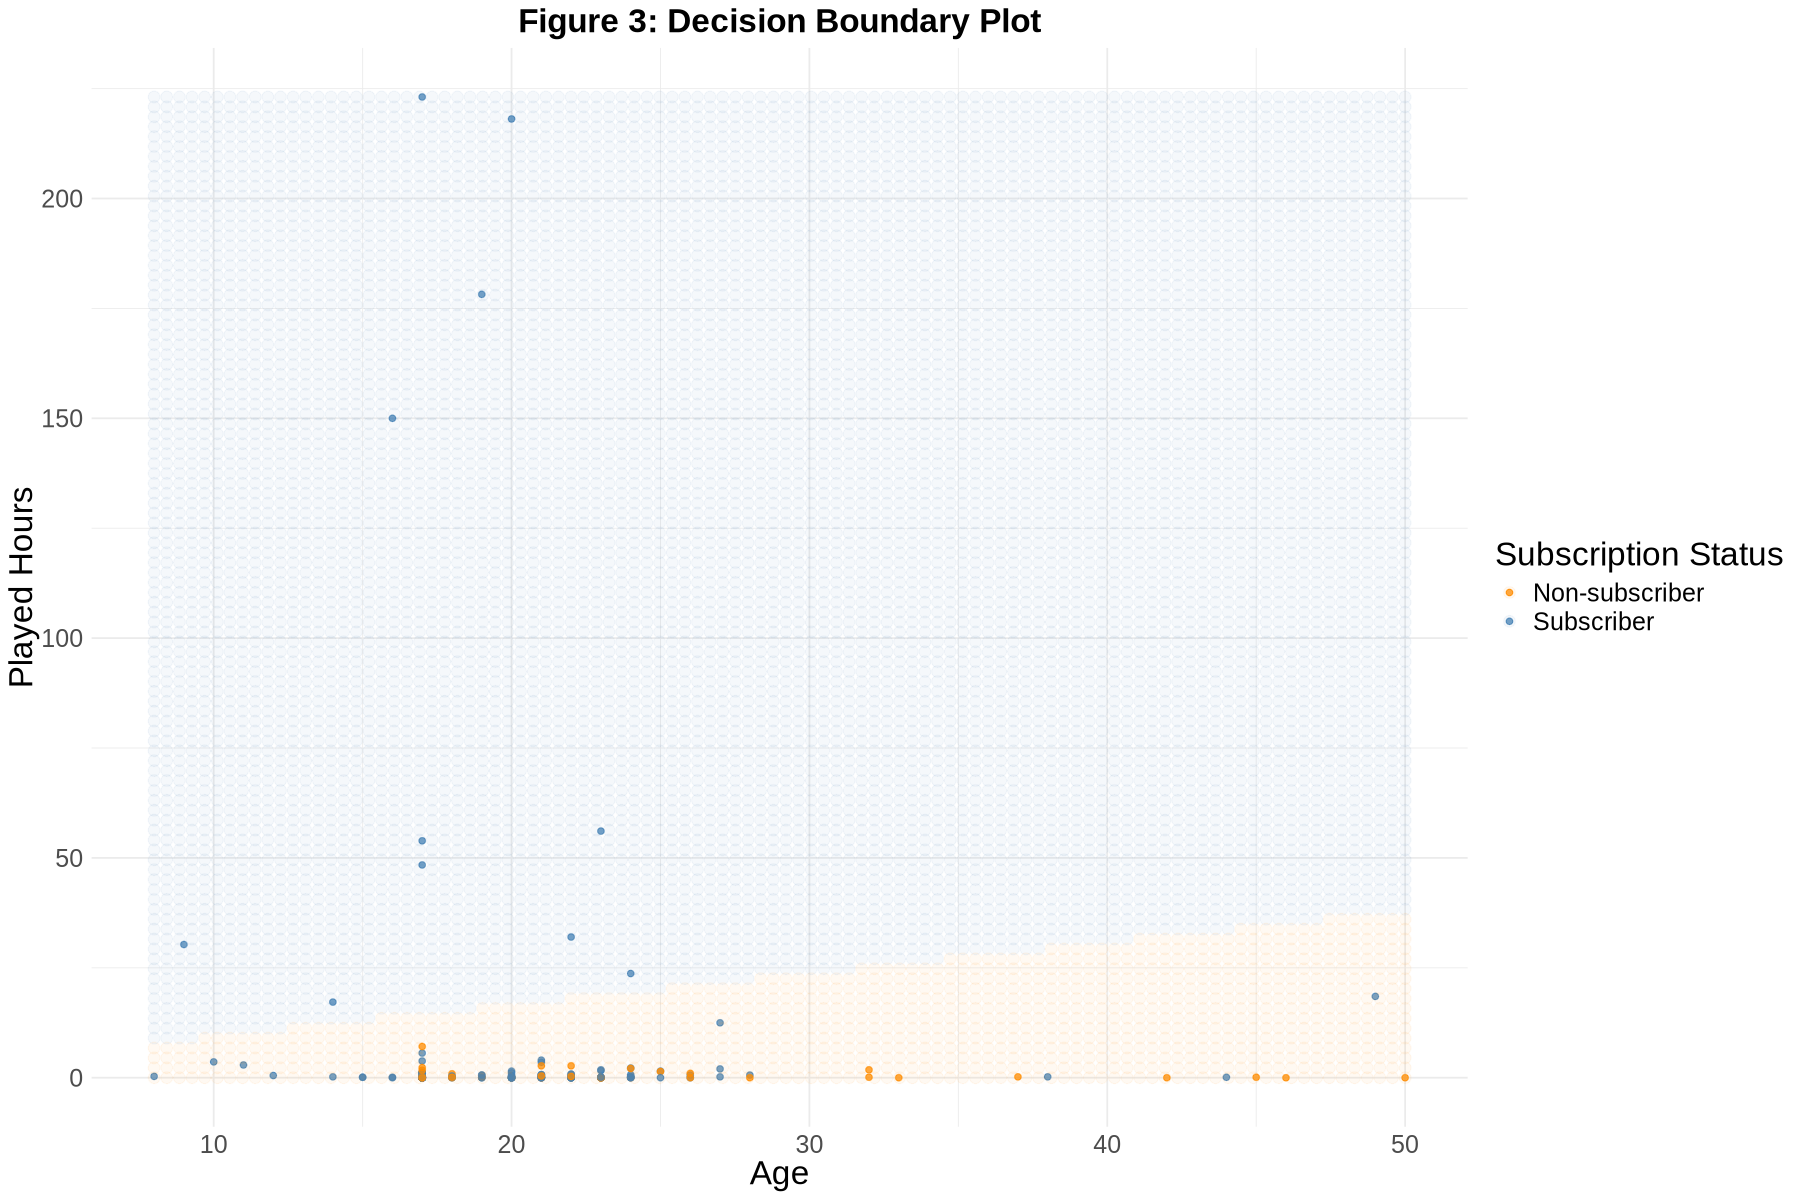

In [45]:
# Create a grid over the range of age and played_hours
age_grid <- seq(min(players$age),
                max(players$age),
                length.out = 100)
hours_grid <- seq(min(players$played_hours),
                  max(players$played_hours),
                  length.out = 100)
grid_points <- as_tibble(expand.grid(age = age_grid,
                                     played_hours = hours_grid))

# Use the knn_fit model to make predictions on the grid points
grid_predictions <- predict(knn_fit, new_data = grid_points)

# Combine the grid points with their predicted subscription status
prediction_table <- bind_cols(grid_predictions, grid_points) |>
  rename(subscriber_status = .pred_class)

# Plot:
# 1. Original players data points colored by subscriber_status
# 2. Faded grid points to display decision boundaries
decision_boundary_plot <- ggplot() +
  geom_point(data = players,
             aes(x = age,
                 y = played_hours,
                 color = subscriber_status),
             alpha = 0.75) +
  geom_point(data = prediction_table,
             aes(x = age,
                 y = played_hours,
                 color = subscriber_status),
             alpha = 0.05,
             size = 3) +
  labs(title = "Figure 3: Decision Boundary Plot",
      color = "Subscription Status",
       x = "Age",
       y = "Played Hours") +
  scale_color_manual(values = c("Non-subscriber" = "darkorange",
                                "Subscriber" = "steelblue")) +
  theme_minimal() +
  theme(text = element_text(size = 12),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
        axis.text.x = element_text(size = 15),                            
        axis.text.y = element_text(size = 15),
        axis.title.x = element_text(size = 20),                           
        axis.title.y = element_text(size = 20),
        legend.title = element_text(size = 20), 
        legend.text = element_text(size = 15))

decision_boundary_plot


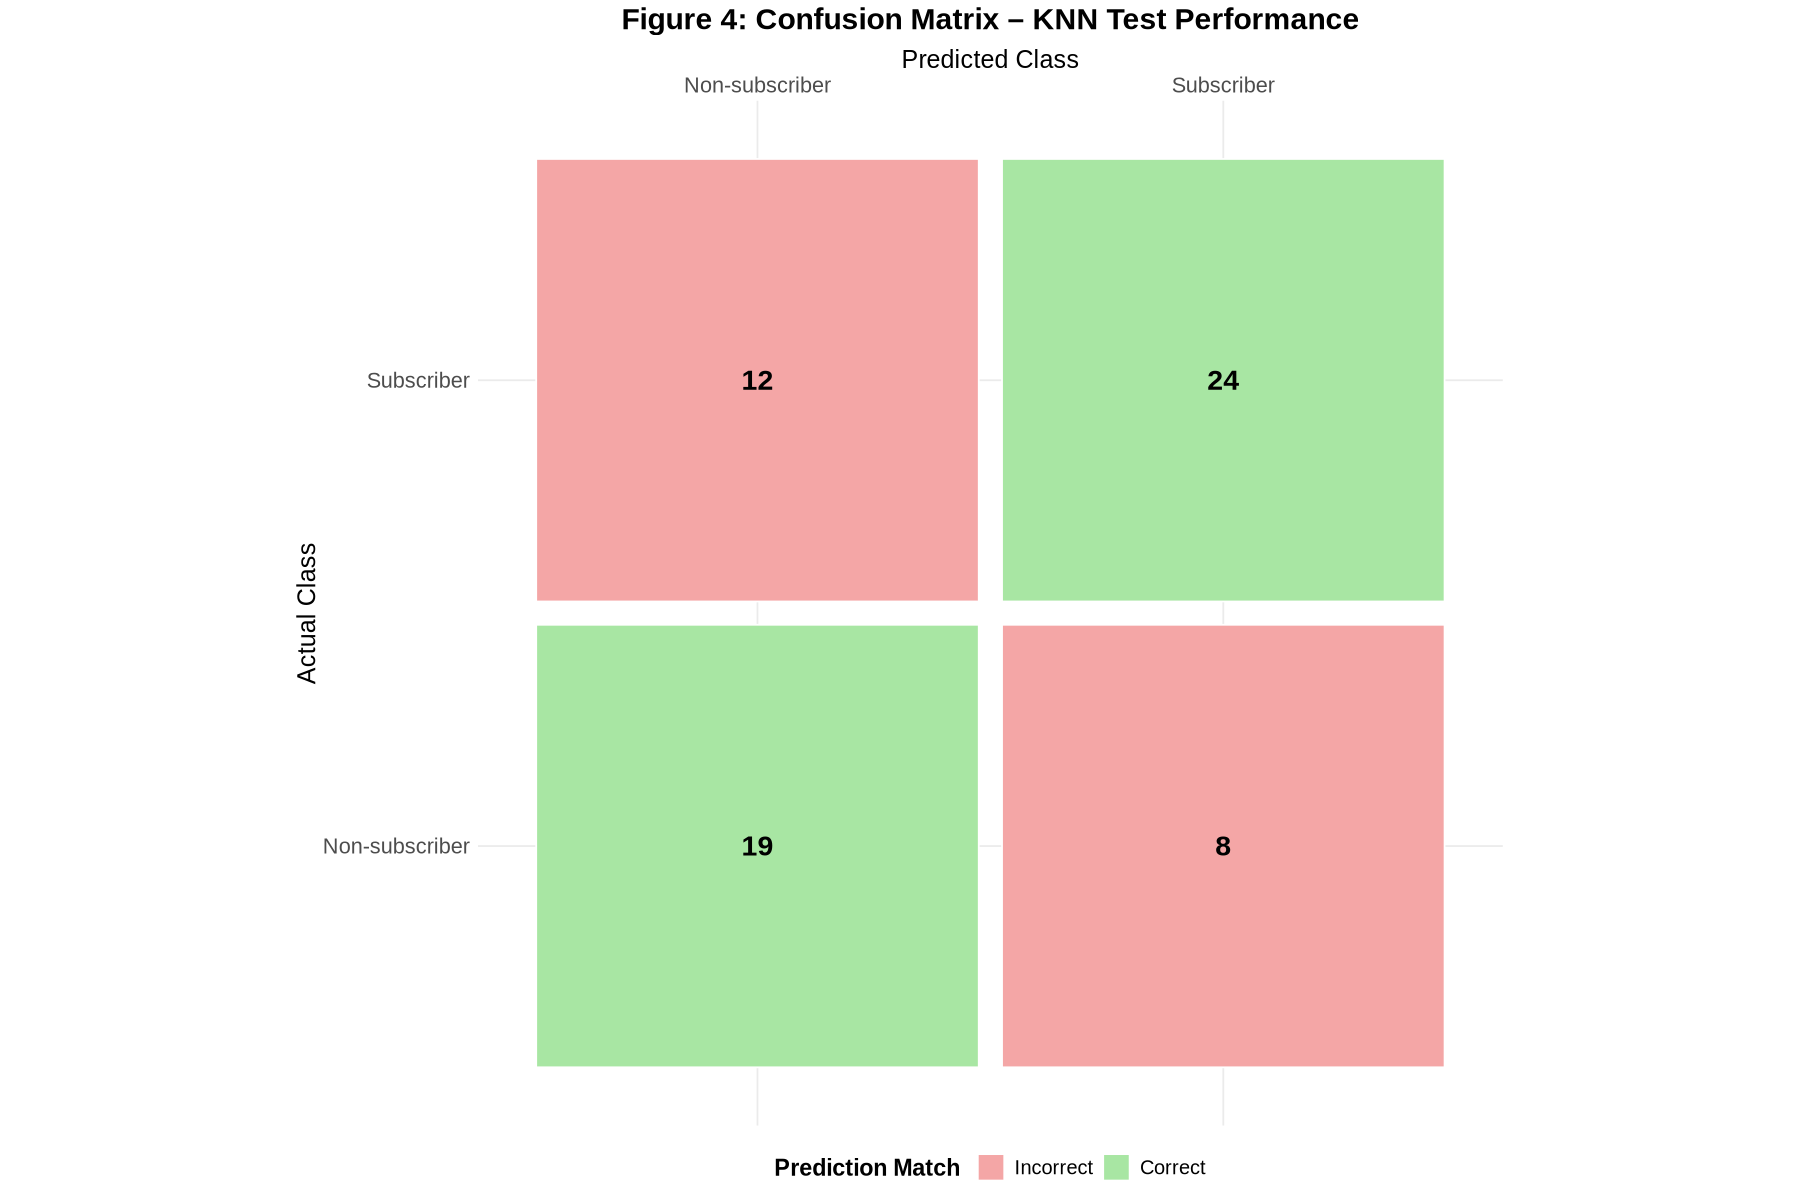

In [38]:

confusion_df <- as.data.frame(confusion$table)

# Mark which cell is a correct prediction
confusion_df$Correct <- confusion_df$Prediction == confusion_df$Truth

# Plot for correct/incorrect
ggplot(confusion_df, aes(x = Prediction, y = Truth, fill = Correct)) +
  geom_tile(width = 0.95, height = 0.95, color = "white", linewidth = 0.5) +
  geom_text(
    aes(label = Freq),
    size = 6,
    fontface = "bold",
    color = "black"
  ) +
  scale_fill_manual(
    values = c(`TRUE` = "#A8E6A3",   
               `FALSE` = "#F4A6A6"),
    labels = c("Incorrect", "Correct")
  ) +
  labs(
    title = "Figure 4: Confusion Matrix – KNN Test Performance",
    x = "Predicted Class",
    y = "Actual Class",
    fill = "Prediction Match"
  ) +
  scale_x_discrete(position = "top") +
  coord_fixed() +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 13),
    legend.position = "bottom",
    legend.title = element_text(face = "bold", size = 14),
    legend.text = element_text(size = 12)
  )




### Method Explanation

We start by loading the player.csv file and the sessions.csv, with a primary focus on the player.csv datasets. We are interested in the players' subscription status, total hours played, and age. After importing the data, we did some basic data wrangling to keep only the relevant columns for our model (played_hours, age subscribe), renamed Age to age for consistency and turned the logical subscription variable into a factor labelled “Non-subscriber” and “Subscriber.” Rows with missing values in our selected columns were removed to make our modelling unaffected by incomplete entries.

With our clean dataset, we generate summary statistics grouped by subscription status. We then created an R recipe to preprocess our data. The recipe centres and scales the predictors (age and played_hours) so that the K-Nearest Neighbors (KNN) algorithm would not be influenced by differences in measurement scales. We also upscale our non-subscribers by 75% to address the imbalance in the dataset. Subscribers significantly outnumbered non-subscribers so we wanted to add extra examples of the minority class (non-subscribers) without making it exactly a 1:1 ratio. This would allow the model to see more examples of the underrepresented class without creating an artificial balance that might cause overfitting.

After this, we produced an exploratory scatter plot (Figure 1) showing how played hours and age varied by subscription status. Each point in this plot indicated a single player, colour-coded to highlight whether they subscribed or not.
Next, we split our data into training and testing sets using stratified sampling based on subscription status. Stratification ensured that both sets had a similar ratio of subscribers to non-subscribers. We then defined a KNN model specification that left the number of neighbours (k) as a tunable parameter. To find the best k, we created 10-fold cross-validation folds on the training set, again stratified by class. We tested values of k from 1 to 40 and repeated this process across 20 random seeds to mitigate the risk of overfitting to any train-test split. The accuracy for each k was recorded and then averaged across seeds to identify which k performed best on average.

We plotted these accuracy results in Figure 2, which shows a line graph of average accuracy against the number of neighbours. The figure has a dashed vertical line at k = 5, indicating the best-performing odd value. We specifically chose an odd k because, in a binary classification setting, even values of k can sometimes result in tie votes among neighbours. The results indicated that while k = 1 or k = 2 gave high accuracy in some splits, these smaller values can overfit by capturing too much local noise and also run the risk of ties at k = 2. Thus, we settled on k = 5 as the final choice because it avoided ties and balanced performance with stability.

With k = 5 selected, we trained the final KNN model on the training set and then generated predictions on the testing set. We measured the model’s performance using metrics like accuracy, Cohen’s Kappa, precision, and recall. We also created a confusion matrix to have a better visualization of the true positives, false positives, true negatives, and false negatives.

To visualize the model’s decision-making, we generated a decision boundary plot (Figure 3) by creating a grid of age and played_hours values, predicting each point’s class, and then overlaying these predictions on top of the actual player data. In the plot, regions of “Subscriber” and “Non-subscriber” predictions appear in colour zones. The original data points show where the model might struggle, especially in areas where players have moderate hours played. The final confusion matrix is presented in Figure 4, which visually maps out how many subscribers and non-subscribers were correctly or incorrectly classified. In the figure, the diagonal cells represent correct classifications (24 non-subscribers and 18 subscribers) while the off-diagonal cells show the mistakes (18 subscribers predicted as non-subscribers, and 3 non-subscribers predicted as subscribers).

## Discussion

### Summarize What You Found

Our analysis of the player dataset showed that subscribers tend to have higher played hours compared to non-subscribers and are generally slightly younger. Through 20 consecutive tunings, we discovered that using an odd number for k (e.g., k = 5) helped avoid tie votes, leading to more consistent predictions. We also measured the model’s performance using metrics like accuracy, Cohen’s Kappa, precision, and recall. Its average accuracy was around 67% while its Cohen’s Kappa was 36%, indicating that the model was only moderately better than random guessing. The model's precision was around 86%, meaning that it was correct most of the time in predicting a player to be a subscriber. However, its recall was around 50%, meaning the model correctly predicted only half of the actual subscribers. While its high precision shows its reliability in confirming subscriptions, its low recall means many actual subscribers are not being detected. The confusion matrix further gives a better illustration of this trade-off. The model correctly predicted 18 subscribers, but it incorrectly classified 18 other subscribers as non-subscribers. On the other hand, the model identified 24 non-subscribers correctly while misclassifying only 3 non-subscribers as subscribers. Our models seem to excel at minimizing false positives among subscribers while struggling significantly with false negatives. This suggests that while the model is cautious in predicting someone as a subscriber, it often fails to recognize actual subscribers, limiting its effectiveness in marketing contexts where identifying all potential subscribers is critical. Based on our findings, these two features provide some predictive value but are not sufficient alone to create a highly reliable model. Incorporating additional player attributes or behaviors may improve both recall and overall model performance.



### Discuss whether this is what you expected to find? Discuss what impact could such findings have?

The two features we focused on for our analysis (played_hours and age) demonstrated that subscribers are generally more engaged (with much higher played hours) and tend to be younger compared to non-subscribers. This supports our hypothesis that these characteristics can predict if a person will subscribe to a game-related newsletter. Players who spend more time in the game and are younger appear to be more likely to be interested in receiving game-related communications. However, our model’s overall accuracy of 67% indicates that age and played_hours aren't enough to understand people's subscription decisions. Additionally, Cohen’s Kappa of 36% suggests a moderate agreement between predicted and actual classes when taking into account class imbalance, reinforcing the idea that these two features are not sufficient to explain subscription behaviour on their own. While the model performs better than random guessing, there is still considerable room for improvement. Its precision of 86% indicates that it usually predicts subscribers accurately. Yet, with only a recall of 50%, it fails to identify half of the actual subscribers. This trade-off between precision and recall highlights the limitations of relying solely on these two metrics. These findings suggest that while higher engagement and a younger demographic are important factors in predicting subscriptions, they do not give a complete picture of why people decide to subscribe or not. That goal in determining the characteristics and behaviours that drive subscription decisions can be done for future research Using more variables for prediction would not only improve the model accuracy but also allow us to understand how different player segments interact with game-related content. This information is valuable to personalized marketing or communication to target certain parts of the player base. For example, our analysis shows that players who subscribe are generally younger and play more than 0 hours. With this info, companies can design a marketing campaign that targets this segment specifically. They could create a newsletter that appeals to a younger, highly engaged audience by displaying exclusive content such as sneak peeks at upcoming game features that would be exclusive to PLAICRAFT servers, behind-the-scenes videos, and early access to new content. The company can also use a separate strategy for less engaged or older players, such as personalized emails offering gameplay tips, updates on the status of the study, or incentives to increase playtime to gradually boost their engagement and interest in subscribing. Changing how companies communicate to each player segment allows the company to convert more players to subscribers and improve overall engagement.

### Discuss what future questions could this lead to?


Starting with variables like played_hours and age gives us a solid foundation in predicting subscription sign-ups. However, we can use other variables to explore player behaviour, such as how often someone logs in or how long they stick around each session. We can also investigate whether players who log in daily or reach certain milestones in the game are more likely to subscribe compared to people with sporadic engagement. We can also explore how demographic factors and cultural differences influence subscription behaviour. Are these observed patterns in Vancouver different in other regions, or do other factors like language, socioeconomic status, or local gaming trends alter the relationship between age, played_hours, and subscription?

## References

- Pacific Laboratory for Artificial Intelligence. (n.d.). *PLAICraft Blog*. Retrieved March 31, 2025, from [https://blog.plaicraft.ai/](https://blog.plaicraft.ai/)  

- Smith, A. (n.d.). *Plaicraft.ai Launch*. Pacific Laboratory for Artificial Intelligence; The University of British Columbia. Retrieved March 31, 2025, from [https://plai.cs.ubc.ca/2023/09/27/plaicraft/](https://plai.cs.ubc.ca/2023/09/27/plaicraft/)  

- Wood, F. (n.d.-a). *Minecraft Meets AI Research*. Pacific Laboratory for Artificial Intelligence; The University of British Columbia. Retrieved March 31, 2025, from [https://plai.cs.ubc.ca/research/minecraft-meets-ai-research-with-plai/](https://plai.cs.ubc.ca/research/minecraft-meets-ai-research-with-plai/)  

- Wood, F. (n.d.-b). *The Pacific Laboratory for Artificial Intelligence*. Pacific Laboratory for Artificial Intelligence (PLAI); The University of British Columbia. Retrieved March 31, 2025, from [https://plai.cs.ubc.ca/](https://plai.cs.ubc.ca/)
